 # 模块三：空间自相关分析实战

 本代码对应课件 Slide 50-60，完整实现以下分析流程：
 1. 探索性数据分析（EDA）
 2. 权重矩阵的构建与选择
 3. 权重矩阵的可视化诊断
 4. Global Moran's I 全局空间自相关检验
 5. LISA 局部空间自相关分析
 6. Getis-Ord Gi* 热点分析
 7. 稳健性检验（多权重对比）

 ---
 **核心研究问题：**
 1. 中国地级市经济发展水平是否存在显著的空间自相关？
 2. 具体在哪些区域形成了热点和冷点？
 3. 分析结果对权重矩阵的选择敏感吗？

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 空间分析核心库
import geopandas as gpd
from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local

# 显示中文（Mac系统）
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("模块三：空间自相关分析——从理论到实践")
print("案例：中国地级市经济发展水平的空间格局")
print("=" * 60)

模块三：空间自相关分析——从理论到实践
案例：中国地级市经济发展水平的空间格局


In [ ]:
# 数据加载与合并
# ---------------------------------------------------------------
# 数据文件位置：
#   城市边界：data/china/city.shp（372个地级市面状多边形）
#   属性数据：data/china/地级市数据.csv（287个城市 × 19年面板数据）

import os

# 数据路径：data/china/ 就在 CODE 目录下
data_dir = 'data/china'

# --- 加载城市边界 shapefile ---
shp_path = os.path.join(data_dir, 'city.shp')
gdf = gpd.read_file(shp_path, encoding='utf-8')
print(f"\n[1] Shapefile 加载完成")
print(f"    路径: {shp_path}")
print(f"    几何类型: {gdf.geometry.type.unique()}")
print(f"    坐标系: {gdf.crs}")
print(f"    城市数: {len(gdf)}")
print(f"    列: {gdf.columns.tolist()}")

# --- 加载属性数据（CSV）---
csv_path = os.path.join(data_dir, '地级市数据.csv')
df_attr = pd.read_csv(csv_path, encoding='utf-8')
print(f"\n[2] CSV 属性数据加载完成")
print(f"    路径: {csv_path}")
print(f"    形状: {df_attr.shape}")
print(f"    年份范围: {df_attr['year'].min()} ~ {df_attr['year'].max()}")
print(f"    可用变量:")
for col in df_attr.columns:
    if col not in ['city', '行政区划代码', 'year', '省份']:
        print(f"      · {col}")


[1] Shapefile 加载完成
    路径: data/china/city.shp
    几何类型: <ArrowStringArray>
['Polygon', 'MultiPolygon']
Length: 2, dtype: str
    坐标系: EPSG:4326
    城市数: 372
    列: ['ct_adcode', 'ct_name', 'pr_adcode', 'pr_name', 'cn_adcode', 'cn_name', 'geometry']

[2] CSV 属性数据加载完成
    路径: data/china/地级市数据.csv
    形状: (5420, 31)
    年份范围: 2003 ~ 2021
    可用变量:
      · 人口规模
      · 人口密度
      · 城市经济密度
      · 经济发展水平
      · 金融发展程度
      · 对外开放水平
      · 城镇化水平
      · 政府干预程度
      · 财政投资力度
      · 财政分权度
      · 产业结构
      · 产业结构整体升级
      · 产业结构高级化
      · 产业结构合理化
      · 教育水平支出
      · 科学技术水平
      · 科教支出
      · 人力资本水平
      · 人力资本
      · 人力资本存量
      · 受教育程度
      · 环境规制
      · 基础设施
      · 专利申请数_件_全市年鉴公布
      · 专利授权数_件_全市年鉴公布
      · 市场化水平
      · 互联网普及率


In [ ]:
# 数据合并：CSV → Shapefile
# ---------------------------------------------------------------
# 选择最新年份（2021）的数据进行分析
ANALYSIS_YEAR = 2021
df_year = df_attr[df_attr['year'] == ANALYSIS_YEAR].copy()
print(f"\n筛选 {ANALYSIS_YEAR} 年数据: {len(df_year)} 个城市")

# ---- 用行政区划代码（adcode）匹配 ----
# CSV: 行政区划代码（int, 如 130100=石家庄, 110000=北京）
# SHP: ct_adcode（str, 如 '130100'=石家庄, '110100'=北京城区）
# 规律：普通城市直接匹配，4个直辖市 XX0000 → SHP中为 XX0100

df_year['adcode'] = df_year['行政区划代码'].astype(str).str.zfill(6)

# 直辖市映射：110000→110100(北京), 120000→120100(天津), 310000→310100(上海), 500000→500100(重庆)
MUNICIPALITY_MAP = {'110000': '110100', '120000': '120100', '310000': '310100', '500000': '500100'}
df_year['adcode_mapped'] = df_year['adcode'].map(lambda c: MUNICIPALITY_MAP.get(c, c))

# 检查匹配情况
csv_codes = set(df_year['adcode_mapped'])
shp_codes = set(gdf['ct_adcode'])
matched = csv_codes & shp_codes

print(f"\n行政区划代码匹配:")
print(f"  匹配成功: {len(matched)}/{len(csv_codes)} 个")
print(f"  （4个直辖市经 XX0000→XX0100 映射后全部匹配）")

# 合并：以 shapefile 为基础，左连接属性数据
gdf_merged = gdf.merge(
    df_year,
    left_on='ct_adcode',
    right_on='adcode_mapped',
    how='left',
    suffixes=('', '_csv')
)

print(f"\n[3] 数据合并完成: {len(gdf_merged)} 个空间单元")
print(f"    成功匹配属性: {gdf_merged['year'].notna().sum()} 个")
print(f"    无属性数据: {gdf_merged['year'].isna().sum()} 个")


筛选 2021 年数据: 287 个城市

行政区划代码匹配:
  匹配成功: 287/287 个
  （4个直辖市经 XX0000→XX0100 映射后全部匹配）

[3] 数据合并完成: 372 个空间单元
    成功匹配属性: 287 个
    无属性数据: 85 个


In [ ]:
# 选择研究变量
# ---------------------------------------------------------------
# 课件中使用"人均GDP"，数据中对应"经济发展水平"（已经是 ln(人均GDP) 形式）
# 这是一个连续变量，非常适合 Moran's I 分析

VAR_NAME = '经济发展水平'
VAR_LABEL = '经济发展水平（ln(人均GDP)）'

# 也可以尝试其他变量：
# VAR_NAME = '城镇化水平'       # 城镇化率
# VAR_NAME = '金融发展程度'     # 金融发展
# VAR_NAME = '产业结构高级化'   # 产业结构
# VAR_NAME = '人口密度'         # 人口密度

print(f"\n研究变量: {VAR_LABEL}")

# 处理缺失值
gdf_valid = gdf_merged.dropna(subset=[VAR_NAME]).copy()
y_values = gdf_valid[VAR_NAME].values.astype(float)

print(f"有效数据量: {len(y_values)} 个城市")
print(f"缺失值: {len(gdf_merged) - len(gdf_valid)} 个（已剔除）")


研究变量: 经济发展水平（ln(人均GDP)）
有效数据量: 287 个城市
缺失值: 85 个（已剔除）


 ---
 # 步骤一：探索性数据分析（EDA）
 对应 Slide 52

In [ ]:
# 1.1 基本统计特征
# ---------------------------------------------------------------
from scipy import stats

print("=" * 60)
print(f"步骤一：探索性数据分析 —— 变量：{VAR_LABEL}")
print("=" * 60)

print("\n【基本统计量】")
print(f"  样本量:   {len(y_values)}")
print(f"  均值:     {np.mean(y_values):.4f}")
print(f"  中位数:   {np.median(y_values):.4f}")
print(f"  标准差:   {np.std(y_values):.4f}")
print(f"  最小值:   {np.min(y_values):.4f}")
print(f"  最大值:   {np.max(y_values):.4f}")
print(f"  偏度:     {stats.skew(y_values):.4f}")
print(f"  峰度:     {stats.kurtosis(y_values):.4f}")

skew_val = stats.skew(y_values)
if abs(skew_val) > 1:
    print(f"\n  注意: 偏度={skew_val:.2f}，分布{'右' if skew_val > 0 else '左'}偏明显！")
    print(f"  建议：考虑对数变换后再做空间自相关分析")
    print(f"  （均值 {np.mean(y_values):.2f} vs 中位数 {np.median(y_values):.2f}）")
else:
    print(f"\n  偏度={skew_val:.2f}，分布近似对称，数据质量良好")
    print(f"  （注意：本变量已经是 ln(人均GDP)，所以接近正态分布）")

步骤一：探索性数据分析 —— 变量：经济发展水平（ln(人均GDP)）

【基本统计量】
  样本量:   287
  均值:     11.0801
  中位数:   11.0168
  标准差:   0.4580
  最小值:   9.8992
  最大值:   12.2928
  偏度:     0.3283
  峰度:     -0.3926

  偏度=0.33，分布近似对称，数据质量良好
  （注意：本变量已经是 ln(人均GDP)，所以接近正态分布）


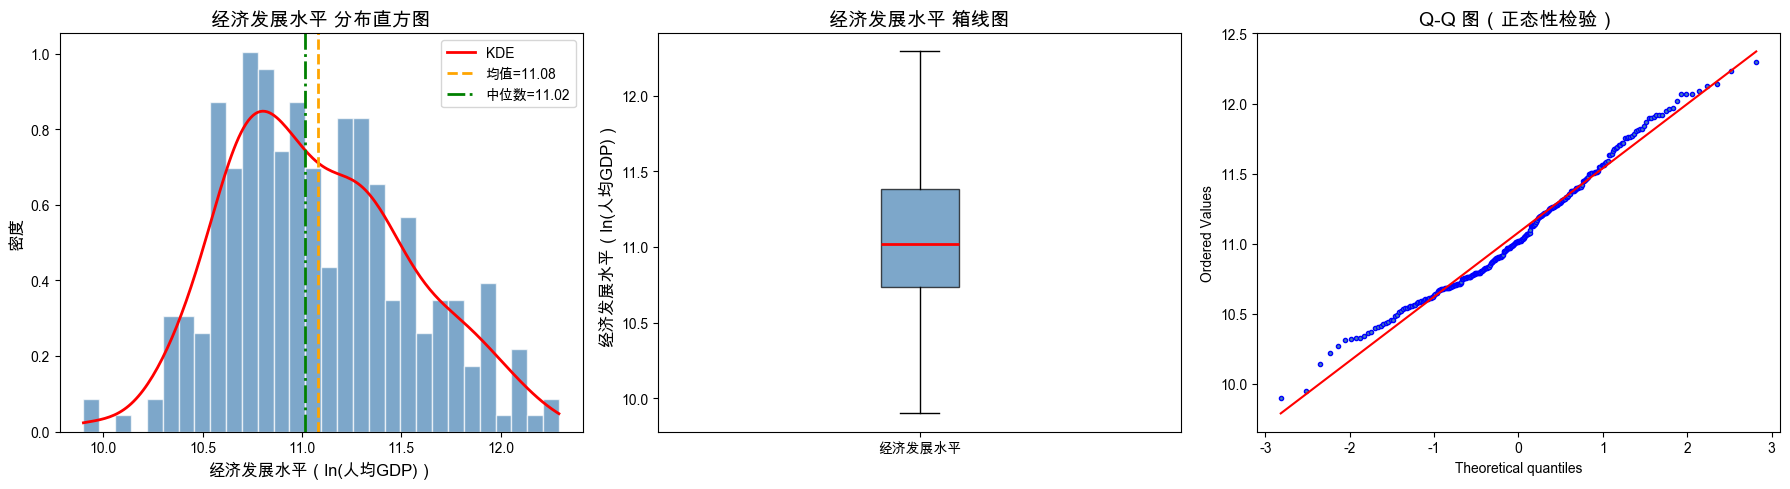


【极端值识别】
  IQR = 0.6494
  正常范围: [9.7614, 12.3591]
  极端值数量: 0 (0.0%)


In [ ]:
# 1.2 分布可视化 —— 直方图 + 箱线图 + QQ图
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) 直方图 + KDE
axes[0].hist(y_values, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='white')
kde_x = np.linspace(y_values.min(), y_values.max(), 200)
kde = stats.gaussian_kde(y_values)
axes[0].plot(kde_x, kde(kde_x), 'r-', linewidth=2, label='KDE')
axes[0].axvline(np.mean(y_values), color='orange', linestyle='--', linewidth=2,
                label=f'均值={np.mean(y_values):.2f}')
axes[0].axvline(np.median(y_values), color='green', linestyle='-.', linewidth=2,
                label=f'中位数={np.median(y_values):.2f}')
axes[0].set_xlabel(VAR_LABEL, fontsize=12)
axes[0].set_ylabel('密度', fontsize=12)
axes[0].set_title(f'{VAR_NAME} 分布直方图', fontsize=14)
axes[0].legend(fontsize=10)

# (b) 箱线图
bp = axes[1].boxplot(y_values, vert=True, patch_artist=True,
                      boxprops=dict(facecolor='steelblue', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2),
                      flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
axes[1].set_ylabel(VAR_LABEL, fontsize=12)
axes[1].set_title(f'{VAR_NAME} 箱线图', fontsize=14)
axes[1].set_xticklabels([VAR_NAME])

# (c) QQ图（检验正态性）
stats.probplot(y_values, plot=axes[2])
axes[2].set_title('Q-Q 图（正态性检验）', fontsize=14)
axes[2].get_lines()[0].set_markerfacecolor('steelblue')
axes[2].get_lines()[0].set_markersize(3)

plt.tight_layout()
plt.savefig('output_01_eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 识别极端值
Q1, Q3 = np.percentile(y_values, [25, 75])
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_mask = (y_values < lower_bound) | (y_values > upper_bound)
n_outliers = np.sum(outliers_mask)

print(f"\n【极端值识别】")
print(f"  IQR = {IQR:.4f}")
print(f"  正常范围: [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"  极端值数量: {n_outliers} ({n_outliers/len(y_values)*100:.1f}%)")

if n_outliers > 0:
    outlier_cities = gdf_valid.loc[gdf_valid.index[outliers_mask], 'ct_name'].tolist()
    print(f"  极端值城市: {outlier_cities[:10]}")

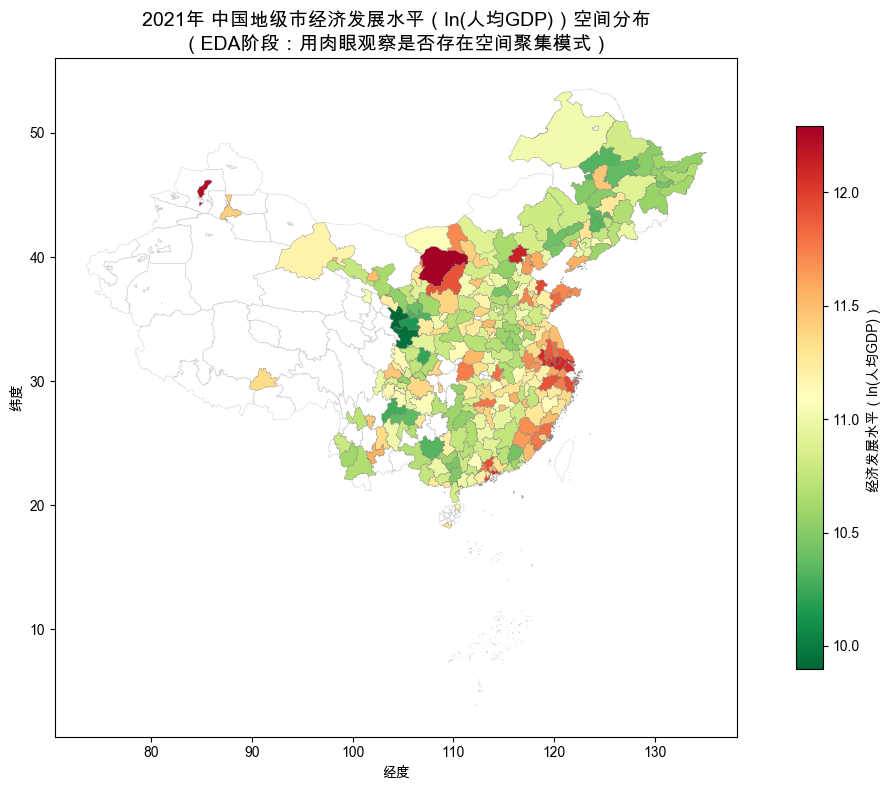


【EDA直觉判断】
  请观察空间分布图，回答以下问题：
  1. 东部沿海城市的值是否明显高于西部内陆？
  2. 是否存在明显的'东部高-西部低'的空间梯度？
  3. 长三角、珠三角、京津冀是否形成高值聚集区？
  4. 有没有异常的城市（局部孤立的高/低值）？
  → 如果看到明显的空间聚集，Moran's I 大概率会显著！


In [ ]:
# 1.3 空间分布可视化 —— "用肉眼看一看"（Slide 52 核心步骤）
# ---------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# 底图：所有城市边界
gdf.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidths=0.3)
# 叠加分析图层
gdf_valid.plot(column=VAR_NAME, cmap='RdYlGn_r', legend=True,
               legend_kwds={'label': VAR_LABEL, 'shrink': 0.8},
               edgecolors='gray', linewidths=0.2, ax=ax)

ax.set_title(f'{ANALYSIS_YEAR}年 中国地级市{VAR_LABEL}空间分布\n'
             f'（EDA阶段：用肉眼观察是否存在空间聚集模式）',
             fontsize=14)
ax.set_xlabel('经度')
ax.set_ylabel('纬度')

plt.tight_layout()
plt.savefig('output_02_spatial_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n【EDA直觉判断】")
print("  请观察空间分布图，回答以下问题：")
print("  1. 东部沿海城市的值是否明显高于西部内陆？")
print("  2. 是否存在明显的'东部高-西部低'的空间梯度？")
print("  3. 长三角、珠三角、京津冀是否形成高值聚集区？")
print("  4. 有没有异常的城市（局部孤立的高/低值）？")
print("  → 如果看到明显的空间聚集，Moran's I 大概率会显著！")

 ---
 # 步骤二：权重矩阵的构建与选择
 对应 Slide 53

In [ ]:
# 2.1 构建三种权重方案：Queen邻接、KNN(4)、KNN(8)
# ---------------------------------------------------------------
print("=" * 60)
print("步骤二：权重矩阵的构建与选择")
print("=" * 60)
print("\n构建三种权重方案进行对比：")

# --- Queen 邻接矩阵（适合面数据）---
# 两个城市共享边界即为邻居
# 问题：中国地级市面积差异巨大，内蒙古城市邻居可能很多
queen_ok = False
try:
    w_queen = Queen.from_dataframe(gdf_valid)
    w_queen.transform = 'r'  # 行标准化
    queen_ok = True
    n_isolates = sum(1 for i in w_queen.isolates)
    avg_neighbors = np.mean([len(v) for v in w_queen.neighbors.values()])
    print(f"\n  [1] Queen 邻接矩阵: 构建成功")
    print(f"      空间单元数: {w_queen.n}")
    print(f"      平均邻居数: {avg_neighbors:.1f}")
    print(f"      孤岛数（无邻居）: {n_isolates}")
except Exception as e:
    print(f"\n  [1] Queen 邻接矩阵: 构建失败 ({e})")

# --- KNN(4) 矩阵 ---
w_knn4 = KNN.from_dataframe(gdf_valid, k=4)
w_knn4.transform = 'r'
print(f"\n  [2] KNN(4) 矩阵: 构建成功")
print(f"      空间单元数: {w_knn4.n}")
print(f"      每个单元固定 4 个邻居")

# --- KNN(8) 矩阵 ---
w_knn8 = KNN.from_dataframe(gdf_valid, k=8)
w_knn8.transform = 'r'
print(f"\n  [3] KNN(8) 矩阵: 构建成功")
print(f"      空间单元数: {w_knn8.n}")
print(f"      每个单元固定 8 个邻居")

# 构建权重方案字典
weight_schemes = {}
if queen_ok:
    weight_schemes['Queen'] = w_queen
weight_schemes['KNN(4)'] = w_knn4
weight_schemes['KNN(8)'] = w_knn8

print(f"\n  共准备 {len(weight_schemes)} 种权重方案")
print("  （多权重对比是空间自相关研究的标准做法——审稿人会问的！）")

步骤二：权重矩阵的构建与选择

构建三种权重方案进行对比：
('WARNING: ', 221, ' is an island (no neighbors)')
('WARNING: ', 222, ' is an island (no neighbors)')
('WARNING: ', 256, ' is an island (no neighbors)')
('WARNING: ', 279, ' is an island (no neighbors)')
('WARNING: ', 285, ' is an island (no neighbors)')
('WARNING: ', 286, ' is an island (no neighbors)')

  [1] Queen 邻接矩阵: 构建失败 ('Queen' object has no attribute 'isolates')

  [2] KNN(4) 矩阵: 构建成功
      空间单元数: 287
      每个单元固定 4 个邻居

  [3] KNN(8) 矩阵: 构建成功
      空间单元数: 287
      每个单元固定 8 个邻居

  共准备 3 种权重方案
  （多权重对比是空间自相关研究的标准做法——审稿人会问的！）


 ---
 # 权重矩阵的可视化诊断（Slide 59 补充内容）
 "权重矩阵质量检查的标准三件套"

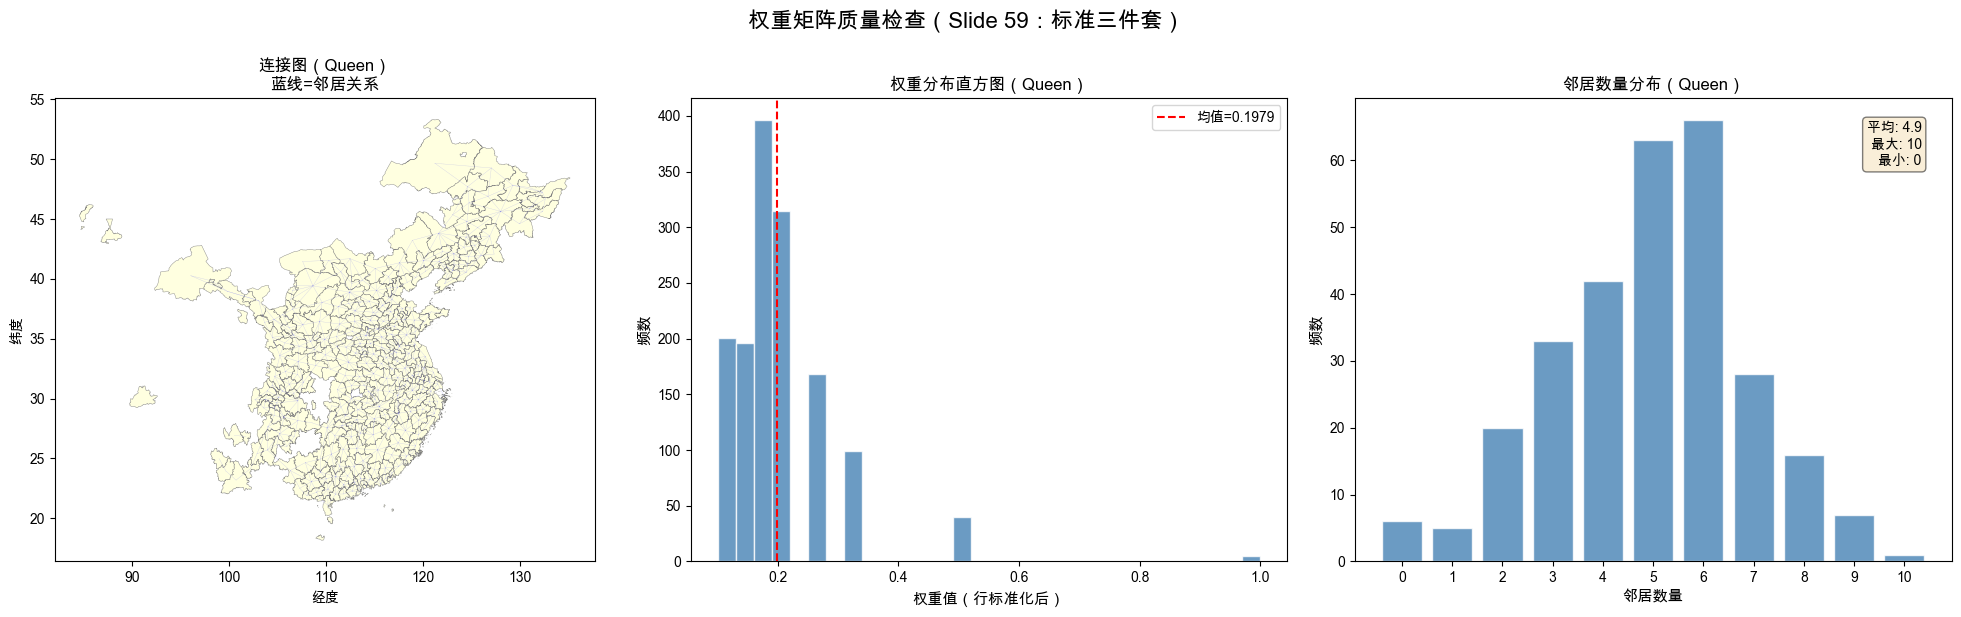


【权重矩阵诊断结论】
  Queen 方案下邻居数差异大（0 ~ 10）
  原因：中国地级市面积差异巨大——内蒙古城市面积大、邻居多
  影响：面积大的城市权重被分散，可能影响分析结果
  → 这就是为什么要同时用 KNN 做稳健性检验！


In [ ]:
# 2.2 权重矩阵可视化 —— 连接图、权重分布、邻居数分布
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('权重矩阵质量检查（Slide 59：标准三件套）', fontsize=16, y=1.02)

# 选择 Queen 方案进行可视化（如果有）
w_demo_name = 'Queen' if queen_ok else 'KNN(4)'
w_demo = weight_schemes[w_demo_name]

# --- (1) 连接图 ---
ax = axes[0]
gdf_valid.plot(ax=ax, facecolor='lightyellow', edgecolor='gray', linewidths=0.3)

# 绘制邻居连接线（用质心连线）
centroids = gdf_valid.geometry.centroid
coord_list = list(zip(centroids.x, centroids.y))
coord_map = dict(zip(range(len(coord_list)), coord_list))

# 只绘制部分连接以保持清晰度
for i, neighbors in w_demo.neighbors.items():
    ci = coord_map.get(i)
    if ci is None:
        continue
    for j in neighbors:
        cj = coord_map.get(j)
        if cj is None:
            continue
        ax.plot([ci[0], cj[0]], [ci[1], cj[1]], 'b-', alpha=0.08, linewidth=0.3)

ax.set_title(f'连接图（{w_demo_name}）\n蓝线=邻居关系', fontsize=12)
ax.set_xlabel('经度')
ax.set_ylabel('纬度')

# --- (2) 权重分布直方图 ---
ax = axes[1]
all_weights = []
for i in w_demo.id_order:
    all_weights.extend(w_demo.weights[i])

ax.hist(all_weights, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('权重值（行标准化后）', fontsize=11)
ax.set_ylabel('频数', fontsize=11)
ax.set_title(f'权重分布直方图（{w_demo_name}）', fontsize=12)
ax.axvline(np.mean(all_weights), color='red', linestyle='--',
           label=f'均值={np.mean(all_weights):.4f}')
ax.legend()

# --- (3) 邻居数量直方图 ---
ax = axes[2]
n_neighbors = [len(w_demo.neighbors[i]) for i in w_demo.id_order]
unique_n = sorted(set(n_neighbors))
counts_n = [n_neighbors.count(n) for n in unique_n]

ax.bar([str(n) for n in unique_n], counts_n, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('邻居数量', fontsize=11)
ax.set_ylabel('频数', fontsize=11)
ax.set_title(f'邻居数量分布（{w_demo_name}）', fontsize=12)

mean_n = np.mean(n_neighbors)
ax.text(0.95, 0.95, f'平均: {mean_n:.1f}\n最大: {max(n_neighbors)}\n最小: {min(n_neighbors)}',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('output_03_weight_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n【权重矩阵诊断结论】")
if w_demo_name == 'Queen':
    if max(n_neighbors) - min(n_neighbors) > 5:
        print(f"  Queen 方案下邻居数差异大（{min(n_neighbors)} ~ {max(n_neighbors)}）")
        print(f"  原因：中国地级市面积差异巨大——内蒙古城市面积大、邻居多")
        print(f"  影响：面积大的城市权重被分散，可能影响分析结果")
        print(f"  → 这就是为什么要同时用 KNN 做稳健性检验！")
else:
    print(f"  KNN 方案下所有单元邻居数固定为 {unique_n[0]}，保证了分析公平性")

 ---
 # 步骤三：Global Moran's I 全局空间自相关检验
 对应 Slide 54

In [ ]:
# 3.1 计算各权重方案下的 Global Moran's I
# ---------------------------------------------------------------
print("=" * 60)
print("步骤三：Global Moran's I 全局空间自相关检验")
print("=" * 60)

moran_results = {}

for name, w in weight_schemes.items():
    moran = Moran(y_values, w, permutations=999)
    moran_results[name] = moran

    print(f"\n{'─' * 50}")
    print(f"  权重方案: {name}")
    print(f"  Moran's I      = {moran.I:.4f}")
    print(f"  期望值 E[I]    = {moran.EI:.6f}")
    print(f"  Z 值           = {moran.z_norm:.4f}")
    print(f"  p 值（正态）   = {moran.p_norm:.6f}")
    print(f"  p 值（排列检验）= {moran.p_sim:.6f}")

    # 结果解读
    if moran.p_sim < 0.001:
        sig = "p < 0.001 ***"
    elif moran.p_sim < 0.01:
        sig = "p < 0.01 **"
    elif moran.p_sim < 0.05:
        sig = "p < 0.05 *"
    else:
        sig = "不显著"

    direction = "正空间自相关（聚集）" if moran.I > 0 else "负空间自相关（离散）"
    print(f"\n  → 解读: {direction}")
    print(f"  → 显著性: {sig}")

    if moran.I > 0:
        print(f"  → 含义: 高值城市倾向与高值城市为邻，低值城市倾向与低值城市为邻")
        print(f"           即'物以类聚'——经济发展水平相似的城市在空间上聚集")
    else:
        print(f"  → 含义: 高值与低值交替分布——'此消彼长'的竞争格局")

步骤三：Global Moran's I 全局空间自相关检验

──────────────────────────────────────────────────
  权重方案: Queen
  Moran's I      = 0.4749
  期望值 E[I]    = -0.003497
  Z 值           = 12.0892
  p 值（正态）   = 0.000000
  p 值（排列检验）= 0.001000

  → 解读: 正空间自相关（聚集）
  → 显著性: p < 0.01 **
  → 含义: 高值城市倾向与高值城市为邻，低值城市倾向与低值城市为邻
           即'物以类聚'——经济发展水平相似的城市在空间上聚集

──────────────────────────────────────────────────
  权重方案: KNN(4)
  Moran's I      = 0.5146
  期望值 E[I]    = -0.003497
  Z 值           = 13.2669
  p 值（正态）   = 0.000000
  p 值（排列检验）= 0.001000

  → 解读: 正空间自相关（聚集）
  → 显著性: p < 0.01 **
  → 含义: 高值城市倾向与高值城市为邻，低值城市倾向与低值城市为邻
           即'物以类聚'——经济发展水平相似的城市在空间上聚集

──────────────────────────────────────────────────
  权重方案: KNN(8)
  Moran's I      = 0.4540
  期望值 E[I]    = -0.003497
  Z 值           = 16.5431
  p 值（正态）   = 0.000000
  p 值（排列检验）= 0.001000

  → 解读: 正空间自相关（聚集）
  → 显著性: p < 0.01 **
  → 含义: 高值城市倾向与高值城市为邻，低值城市倾向与低值城市为邻
           即'物以类聚'——经济发展水平相似的城市在空间上聚集


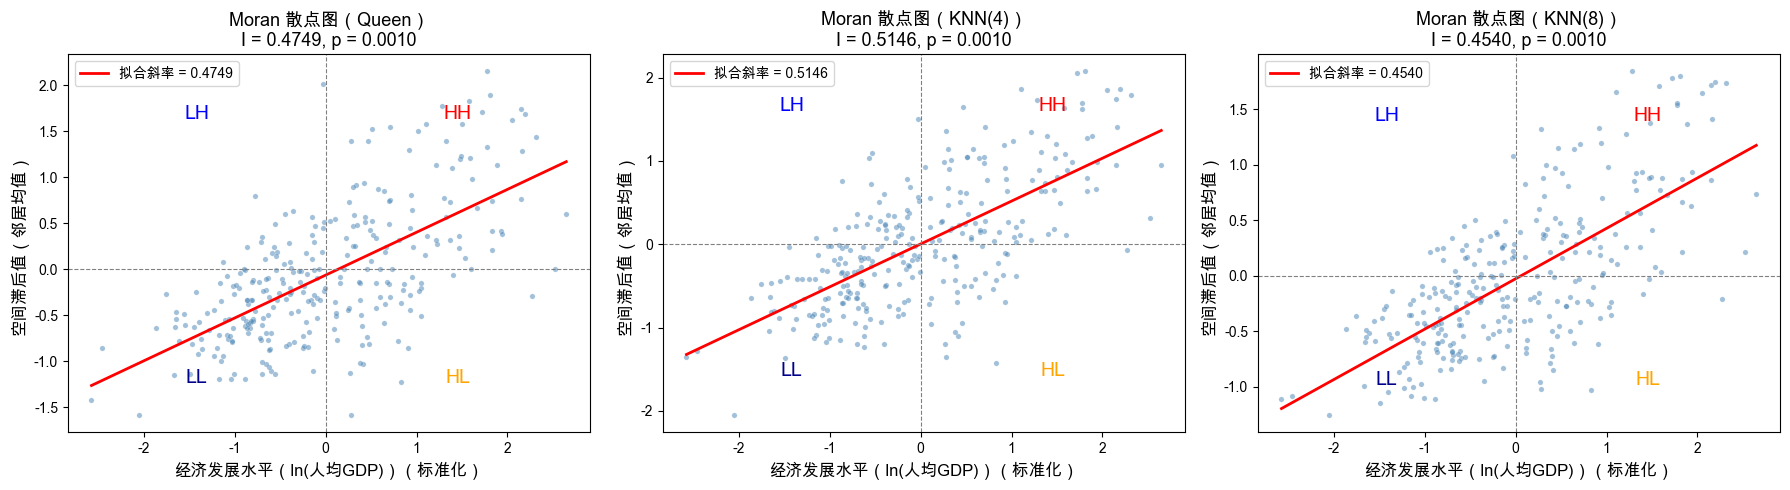


【Moran 散点图各象限统计】

  Queen:
    HH（高-高，自己高邻居也高）: 79 (27.5%)
    LL（低-低，自己低邻居也低）: 130 (45.3%)
    HL（高-低，自己高邻居低）  : 44 (15.3%)
    LH（低-高，自己低邻居高）  : 28 (9.8%)

  KNN(4):
    HH（高-高，自己高邻居也高）: 94 (32.8%)
    LL（低-低，自己低邻居也低）: 122 (42.5%)
    HL（高-低，自己高邻居低）  : 34 (11.8%)
    LH（低-高，自己低邻居高）  : 37 (12.9%)

  KNN(8):
    HH（高-高，自己高邻居也高）: 86 (30.0%)
    LL（低-低，自己低邻居也低）: 127 (44.3%)
    HL（高-低，自己高邻居低）  : 42 (14.6%)
    LH（低-高，自己低邻居高）  : 32 (11.1%)


In [ ]:
# 3.2 Moran 散点图
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, len(moran_results), figsize=(6 * len(moran_results), 5))
if len(moran_results) == 1:
    axes = [axes]

for idx, (name, moran) in enumerate(moran_results.items()):
    ax = axes[idx]
    w = weight_schemes[name]

    # 标准化变量
    y_std = (y_values - y_values.mean()) / y_values.std()
    # 计算空间滞后
    lag = w.sparse.dot(y_std)

    ax.scatter(y_std, lag, s=15, alpha=0.5, c='steelblue',
               edgecolors='white', linewidths=0.3)

    # 趋势线（斜率 ≈ Moran's I）
    fit = np.polyfit(y_std, lag, 1)
    x_line = np.linspace(y_std.min(), y_std.max(), 100)
    ax.plot(x_line, np.polyval(fit, x_line), 'r-', linewidth=2,
            label=f"拟合斜率 = {moran.I:.4f}")

    # 象限分割线
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)

    # 标注四个象限
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.text(xlim[1]*0.5, ylim[1]*0.7, 'HH', fontsize=14, color='red',
            fontweight='bold', ha='center')
    ax.text(xlim[0]*0.5, ylim[1]*0.7, 'LH', fontsize=14, color='blue',
            fontweight='bold', ha='center')
    ax.text(xlim[0]*0.5, ylim[0]*0.7, 'LL', fontsize=14, color='darkblue',
            fontweight='bold', ha='center')
    ax.text(xlim[1]*0.5, ylim[0]*0.7, 'HL', fontsize=14, color='orange',
            fontweight='bold', ha='center')

    ax.set_xlabel(f'{VAR_LABEL}（标准化）', fontsize=12)
    ax.set_ylabel('空间滞后值（邻居均值）', fontsize=12)
    ax.set_title(f"Moran 散点图（{name}）\nI = {moran.I:.4f}, p = {moran.p_sim:.4f}",
                 fontsize=13)
    ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('output_04_moran_scatterplot.png', dpi=150, bbox_inches='tight')
plt.show()

# 统计各象限的点数
print("\n【Moran 散点图各象限统计】")
for name, moran in moran_results.items():
    w = weight_schemes[name]
    y_std = (y_values - y_values.mean()) / y_values.std()
    lag = w.sparse.dot(y_std)

    hh = np.sum((y_std > 0) & (lag > 0))
    lh = np.sum((y_std < 0) & (lag > 0))
    ll = np.sum((y_std < 0) & (lag < 0))
    hl = np.sum((y_std > 0) & (lag < 0))

    print(f"\n  {name}:")
    print(f"    HH（高-高，自己高邻居也高）: {hh} ({hh/len(y_std)*100:.1f}%)")
    print(f"    LL（低-低，自己低邻居也低）: {ll} ({ll/len(y_std)*100:.1f}%)")
    print(f"    HL（高-低，自己高邻居低）  : {hl} ({hl/len(y_std)*100:.1f}%)")
    print(f"    LH（低-高，自己低邻居高）  : {lh} ({lh/len(y_std)*100:.1f}%)")

 ---
 # 步骤四：LISA 局部空间自相关分析
 对应 Slide 55

In [ ]:
# 4.1 计算 LISA（Local Moran's I）
# ---------------------------------------------------------------
print("=" * 60)
print("步骤四：LISA 局部空间自相关分析")
print("=" * 60)

# 使用 Queen 邻接矩阵作为主方案（如果有）
primary_w_name = 'Queen' if queen_ok else list(weight_schemes.keys())[0]
primary_w = weight_schemes[primary_w_name]

lisa = Moran_Local(y_values, primary_w, permutations=999)

# 分类：基于象限 + 显著性（p < 0.05）
labels = lisa.q  # 象限 (1=HH, 2=LH, 3=LL, 4=HL)
significant = lisa.p_sim <= 0.05

lisa_class = np.zeros(len(y_values), dtype=int)
lisa_class[significant & (labels == 1)] = 1  # HH
lisa_class[significant & (labels == 2)] = 2  # LH
lisa_class[significant & (labels == 3)] = 3  # LL
lisa_class[significant & (labels == 4)] = 4  # HL

class_names = {
    0: '不显著', 1: 'HH（高-高）', 2: 'LH（低-高）',
    3: 'LL（低-低）', 4: 'HL（高-低）'
}
print(f"\n权重方案: {primary_w_name}")
print(f"LISA 聚类结果（p < 0.05 显著性水平）:")
for c in [1, 3, 2, 4, 0]:
    count = np.sum(lisa_class == c)
    pct = count / len(y_values) * 100
    print(f"  {class_names[c]}: {count} 个城市 ({pct:.1f}%)")

# 列出 HH 和 LL 的具体城市
if np.sum(lisa_class == 1) > 0:
    hh_cities = gdf_valid.loc[gdf_valid.index[lisa_class == 1], 'ct_name'].tolist()
    print(f"\n  HH 热点城市（示例）: {hh_cities[:15]}")
if np.sum(lisa_class == 3) > 0:
    ll_cities = gdf_valid.loc[gdf_valid.index[lisa_class == 3], 'ct_name'].tolist()
    print(f"  LL 冷点城市（示例）: {ll_cities[:15]}")

步骤四：LISA 局部空间自相关分析

权重方案: Queen
LISA 聚类结果（p < 0.05 显著性水平）:
  HH（高-高）: 34 个城市 (11.8%)
  LL（低-低）: 36 个城市 (12.5%)
  LH（低-高）: 2 个城市 (0.7%)
  HL（高-低）: 11 个城市 (3.8%)
  不显著: 204 个城市 (71.1%)

  HH 热点城市（示例）: ['呼和浩特市', '乌海市', '鄂尔多斯市', '上海城区', '南京市', '无锡市', '常州市', '苏州市', '南通市', '淮安市', '盐城市', '扬州市', '镇江市', '泰州市', '杭州市']
  LL 冷点城市（示例）: ['石家庄市', '通辽市', '呼伦贝尔市', '朝阳市', '四平市', '辽源市', '哈尔滨市', '鸡西市', '鹤岗市', '双鸭山市', '伊春市', '佳木斯市', '七台河市', '牡丹江市', '黑河市']


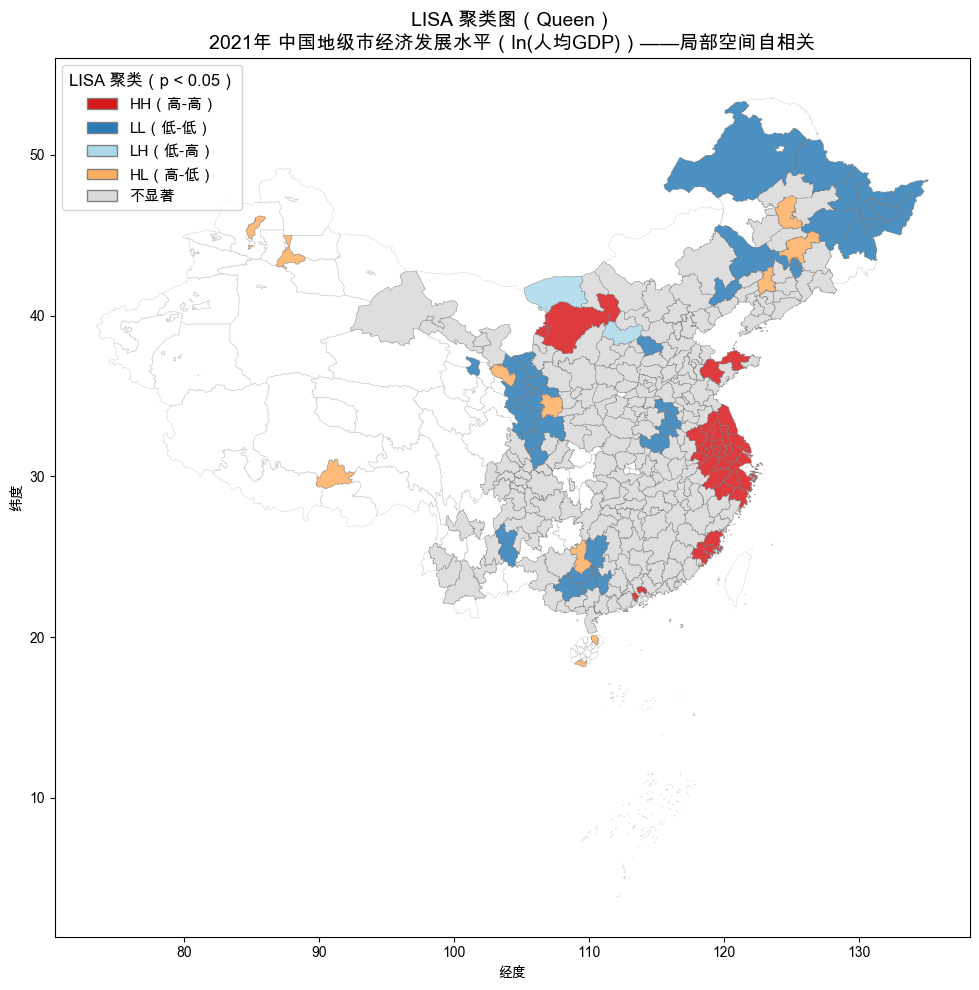


【LISA 聚类图解读】（对应 Slide 55）
  重点：只有通过显著性检验（p < 0.05）的城市才被着色！
  灰色城市 = 不显著，其'聚集'可能只是随机噪音。

  HH（红色）：高值被高值包围 → 经济发达的聚集区
             可能是长三角、珠三角、京津冀等城市群
  LL（蓝色）：低值被低值包围 → 经济欠发达的聚集区
             可能是西部、东北等地区
  HL（橙色）：高值被低值包围 → 空间异常值（如资源型城市）
  LH（浅蓝）：低值被高值包围 → 被发达邻居包围的欠发达城市


In [ ]:
# 4.2 LISA 聚类图
# ---------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# 底图：所有城市边界
gdf.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidths=0.3)

colors = {
    0: '#d9d9d9',   # 不显著 - 浅灰
    1: '#d7191c',   # HH - 红色
    2: '#abd9e9',   # LH - 浅蓝
    3: '#2c7bb6',   # LL - 深蓝
    4: '#fdae61',   # HL - 橙色
}

gdf_valid['lisa_class'] = lisa_class
for cls, color in colors.items():
    mask = gdf_valid['lisa_class'] == cls
    if mask.any():
        gdf_valid[mask].plot(ax=ax, facecolor=color,
                              edgecolors='gray', linewidths=0.3,
                              label=class_names[cls], alpha=0.85)

legend_elements = [Patch(facecolor=colors[c], edgecolor='gray', label=class_names[c])
                   for c in [1, 3, 2, 4, 0] if np.sum(lisa_class == c) > 0]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
          title='LISA 聚类（p < 0.05）', title_fontsize=12)

ax.set_title(f'LISA 聚类图（{primary_w_name}）\n'
             f'{ANALYSIS_YEAR}年 中国地级市{VAR_LABEL}——局部空间自相关',
             fontsize=14)
ax.set_xlabel('经度')
ax.set_ylabel('纬度')

plt.tight_layout()
plt.savefig('output_05_lisa_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n【LISA 聚类图解读】（对应 Slide 55）")
print("  重点：只有通过显著性检验（p < 0.05）的城市才被着色！")
print("  灰色城市 = 不显著，其'聚集'可能只是随机噪音。")
print()
print("  HH（红色）：高值被高值包围 → 经济发达的聚集区")
print("             可能是长三角、珠三角、京津冀等城市群")
print("  LL（蓝色）：低值被低值包围 → 经济欠发达的聚集区")
print("             可能是西部、东北等地区")
print("  HL（橙色）：高值被低值包围 → 空间异常值（如资源型城市）")
print("  LH（浅蓝）：低值被高值包围 → 被发达邻居包围的欠发达城市")

 ---
 # 步骤五：Getis-Ord Gi* 热点分析
 对应 Slide 56

In [ ]:
# 5.1 计算 Getis-Ord Gi*
# ---------------------------------------------------------------
print("=" * 60)
print("步骤五：Getis-Ord Gi* 热点分析")
print("=" * 60)

gi_star = G_Local(y_values, primary_w, star=True, permutations=999)

gi_z = gi_star.Zs
gi_p = gi_star.p_sim

print(f"\n权重方案: {primary_w_name}")
print(f"Gi* Z值范围: [{gi_z.min():.4f}, {gi_z.max():.4f}]")

print(f"\nGi* 热点/冷点统计:")
hot_99 = np.sum((gi_z > 0) & (gi_p < 0.01))
hot_95 = np.sum((gi_z > 0) & (gi_p >= 0.01) & (gi_p < 0.05))
hot_90 = np.sum((gi_z > 0) & (gi_p >= 0.05) & (gi_p < 0.10))
cold_99 = np.sum((gi_z < 0) & (gi_p < 0.01))
cold_95 = np.sum((gi_z < 0) & (gi_p >= 0.01) & (gi_p < 0.05))
cold_90 = np.sum((gi_z < 0) & (gi_p >= 0.05) & (gi_p < 0.10))
not_sig = np.sum(gi_p >= 0.10)

print(f"  热点（99%置信）: {hot_99} 个城市")
print(f"  热点（95%置信）: {hot_95} 个城市")
print(f"  热点（90%置信）: {hot_90} 个城市")
print(f"  冷点（99%置信）: {cold_99} 个城市")
print(f"  冷点（95%置信）: {cold_95} 个城市")
print(f"  冷点（90%置信）: {cold_90} 个城市")
print(f"  不显著:         {not_sig} 个城市")

步骤五：Getis-Ord Gi* 热点分析
('WARNING: ', 221, ' is an island (no neighbors)')
('WARNING: ', 222, ' is an island (no neighbors)')
('WARNING: ', 256, ' is an island (no neighbors)')
('WARNING: ', 279, ' is an island (no neighbors)')
('WARNING: ', 285, ' is an island (no neighbors)')
('WARNING: ', 286, ' is an island (no neighbors)')

权重方案: Queen
Gi* Z值范围: [nan, nan]

Gi* 热点/冷点统计:
  热点（99%置信）: 21 个城市
  热点（95%置信）: 15 个城市
  热点（90%置信）: 12 个城市
  冷点（99%置信）: 14 个城市
  冷点（95%置信）: 28 个城市
  冷点（90%置信）: 26 个城市
  不显著:         165 个城市


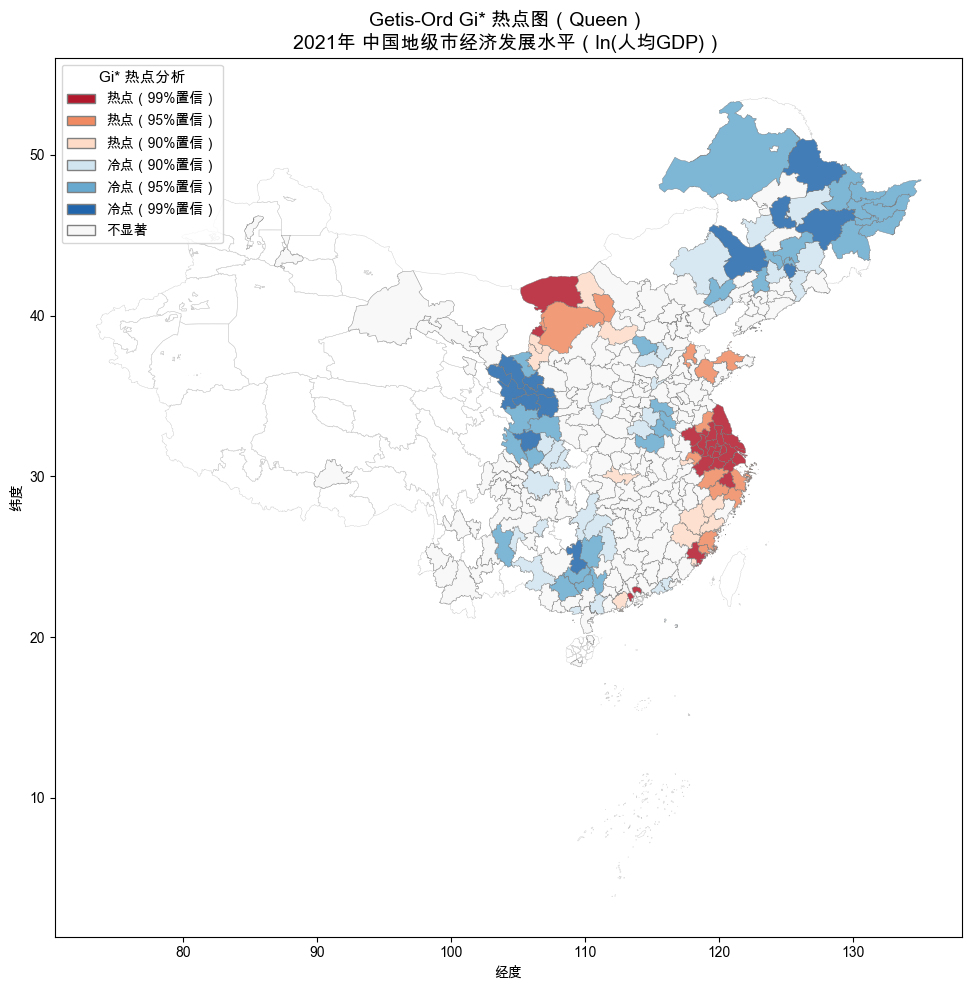


【Gi* 热点图 vs LISA 聚类图】（对应 Slide 56）
  Gi* 优势：简洁（只有红蓝两种），适合向政策制定者汇报
  Gi* 优势：包含自身值，结果更平滑稳定
  Gi* 短板：无法识别空间异常值（HL 和 LH）
  最佳实践：LISA 图 + Gi* 图 一起画，互补使用！


In [ ]:
# 5.2 Gi* 热点图
# ---------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# 底图：所有城市边界
gdf.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidths=0.3)

gi_class = np.zeros(len(y_values), dtype=int)
gi_class[(gi_z > 0) & (gi_p < 0.01)] = 3
gi_class[(gi_z > 0) & (gi_p >= 0.01) & (gi_p < 0.05)] = 2
gi_class[(gi_z > 0) & (gi_p >= 0.05) & (gi_p < 0.10)] = 1
gi_class[(gi_z < 0) & (gi_p < 0.01)] = -3
gi_class[(gi_z < 0) & (gi_p >= 0.01) & (gi_p < 0.05)] = -2
gi_class[(gi_z < 0) & (gi_p >= 0.05) & (gi_p < 0.10)] = -1

gi_colors = {
    -3: '#2166ac', -2: '#67a9cf', -1: '#d1e5f0',
    0:  '#f7f7f7',
    1:  '#fddbc7', 2:  '#ef8a62', 3:  '#b2182b',
}
gi_labels = {
    -3: '冷点（99%置信）', -2: '冷点（95%置信）', -1: '冷点（90%置信）',
    0:  '不显著',
    1:  '热点（90%置信）', 2:  '热点（95%置信）', 3:  '热点（99%置信）',
}

gdf_valid['gi_class'] = gi_class
for cls in [3, 2, 1, -1, -2, -3, 0]:
    mask = gdf_valid['gi_class'] == cls
    if mask.any():
        gdf_valid[mask].plot(ax=ax, facecolor=gi_colors[cls],
                              edgecolors='gray', linewidths=0.3,
                              label=gi_labels[cls], alpha=0.85)

legend_elements = [Patch(facecolor=gi_colors[c], edgecolor='gray', label=gi_labels[c])
                   for c in [3, 2, 1, -1, -2, -3, 0] if np.sum(gi_class == c) > 0]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10,
          title='Gi* 热点分析', title_fontsize=11)

ax.set_title(f'Getis-Ord Gi* 热点图（{primary_w_name}）\n'
             f'{ANALYSIS_YEAR}年 中国地级市{VAR_LABEL}',
             fontsize=14)
ax.set_xlabel('经度')
ax.set_ylabel('纬度')

plt.tight_layout()
plt.savefig('output_06_gistar_hotspot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n【Gi* 热点图 vs LISA 聚类图】（对应 Slide 56）")
print("  Gi* 优势：简洁（只有红蓝两种），适合向政策制定者汇报")
print("  Gi* 优势：包含自身值，结果更平滑稳定")
print("  Gi* 短板：无法识别空间异常值（HL 和 LH）")
print("  最佳实践：LISA 图 + Gi* 图 一起画，互补使用！")

 ---
 # 步骤六：稳健性检验
 对应 Slide 57-58

In [ ]:
# 6.1 多权重方案的 Global Moran's I 对比
# ---------------------------------------------------------------
print("=" * 60)
print("步骤六：稳健性检验（多权重方案对比）")
print("=" * 60)

print(f"\n【Global Moran's I 稳健性对比】")
print(f"{'权重方案':<12} {'Moran I':>10} {'Z值':>10} {'p值(排列)':>12} {'方向':>6}")
print("─" * 55)

all_positive = True
all_significant = True

for name, moran in moran_results.items():
    direction = "正" if moran.I > 0 else "负"
    print(f"{name:<12} {moran.I:>10.4f} {moran.z_norm:>10.4f} {moran.p_sim:>12.6f} {direction:>6}")
    if moran.I <= 0:
        all_positive = False
    if moran.p_sim >= 0.05:
        all_significant = False

print("─" * 55)
print("\n【稳健性判断】")
if all_positive and all_significant:
    print("  ✓ 方向一致：所有权重方案下 Moran's I 均为正")
    print("  ✓ 显著性一致：所有方案下 p < 0.001，高度显著")
    print("  → 结论：全局空间自相关的结论是稳健的！")
    print("  → 审稿人不会因为权重选择问题质疑你的结论")
else:
    print("  ⚠️ 不同权重方案下结论不完全一致，需谨慎解读")

步骤六：稳健性检验（多权重方案对比）

【Global Moran's I 稳健性对比】
权重方案            Moran I         Z值       p值(排列)     方向
───────────────────────────────────────────────────────
Queen            0.4749    12.0892     0.001000      正
KNN(4)           0.5146    13.2669     0.001000      正
KNN(8)           0.4540    16.5431     0.001000      正
───────────────────────────────────────────────────────

【稳健性判断】
  ✓ 方向一致：所有权重方案下 Moran's I 均为正
  ✓ 显著性一致：所有方案下 p < 0.001，高度显著
  → 结论：全局空间自相关的结论是稳健的！
  → 审稿人不会因为权重选择问题质疑你的结论


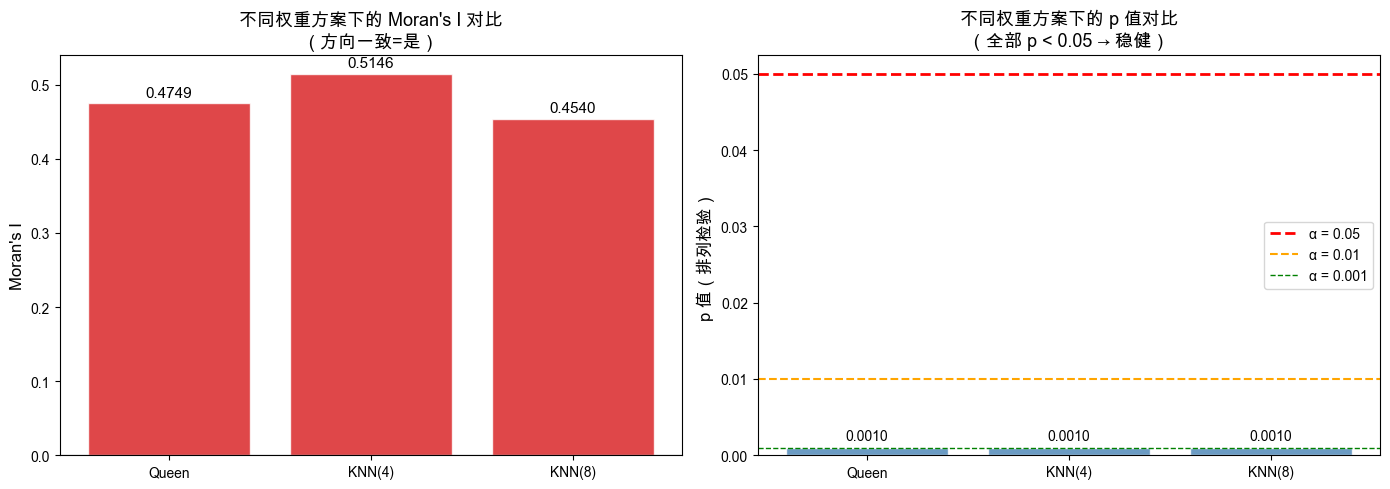

In [ ]:
# 6.2 稳健性可视化
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(moran_results.keys())
i_values = [moran_results[n].I for n in names]
p_values = [moran_results[n].p_sim for n in names]

# (a) Moran's I 对比柱状图
colors_bar = ['#d7191c' if v > 0 else '#2c7bb6' for v in i_values]
bars = axes[0].bar(names, i_values, color=colors_bar, edgecolor='white', alpha=0.8)
axes[0].axhline(y=0, color='black', linewidth=0.8)
for bar, val in zip(bars, i_values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylabel("Moran's I", fontsize=12)
axes[0].set_title(f'不同权重方案下的 Moran\'s I 对比\n（方向一致={("是" if all_positive else "否")}）',
                  fontsize=13)

# (b) p 值对比柱状图
axes[1].bar(names, p_values, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
axes[1].axhline(y=0.01, color='orange', linestyle='--', linewidth=1.5, label='α = 0.01')
axes[1].axhline(y=0.001, color='green', linestyle='--', linewidth=1, label='α = 0.001')
for i_p, (n, p) in enumerate(zip(names, p_values)):
    axes[1].text(i_p, max(p, 0.001) + 0.001, f'{p:.4f}', ha='center', fontsize=10)
axes[1].set_ylabel('p 值（排列检验）', fontsize=12)
axes[1].set_title('不同权重方案下的 p 值对比\n（全部 p < 0.05 → 稳健）', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('output_07_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

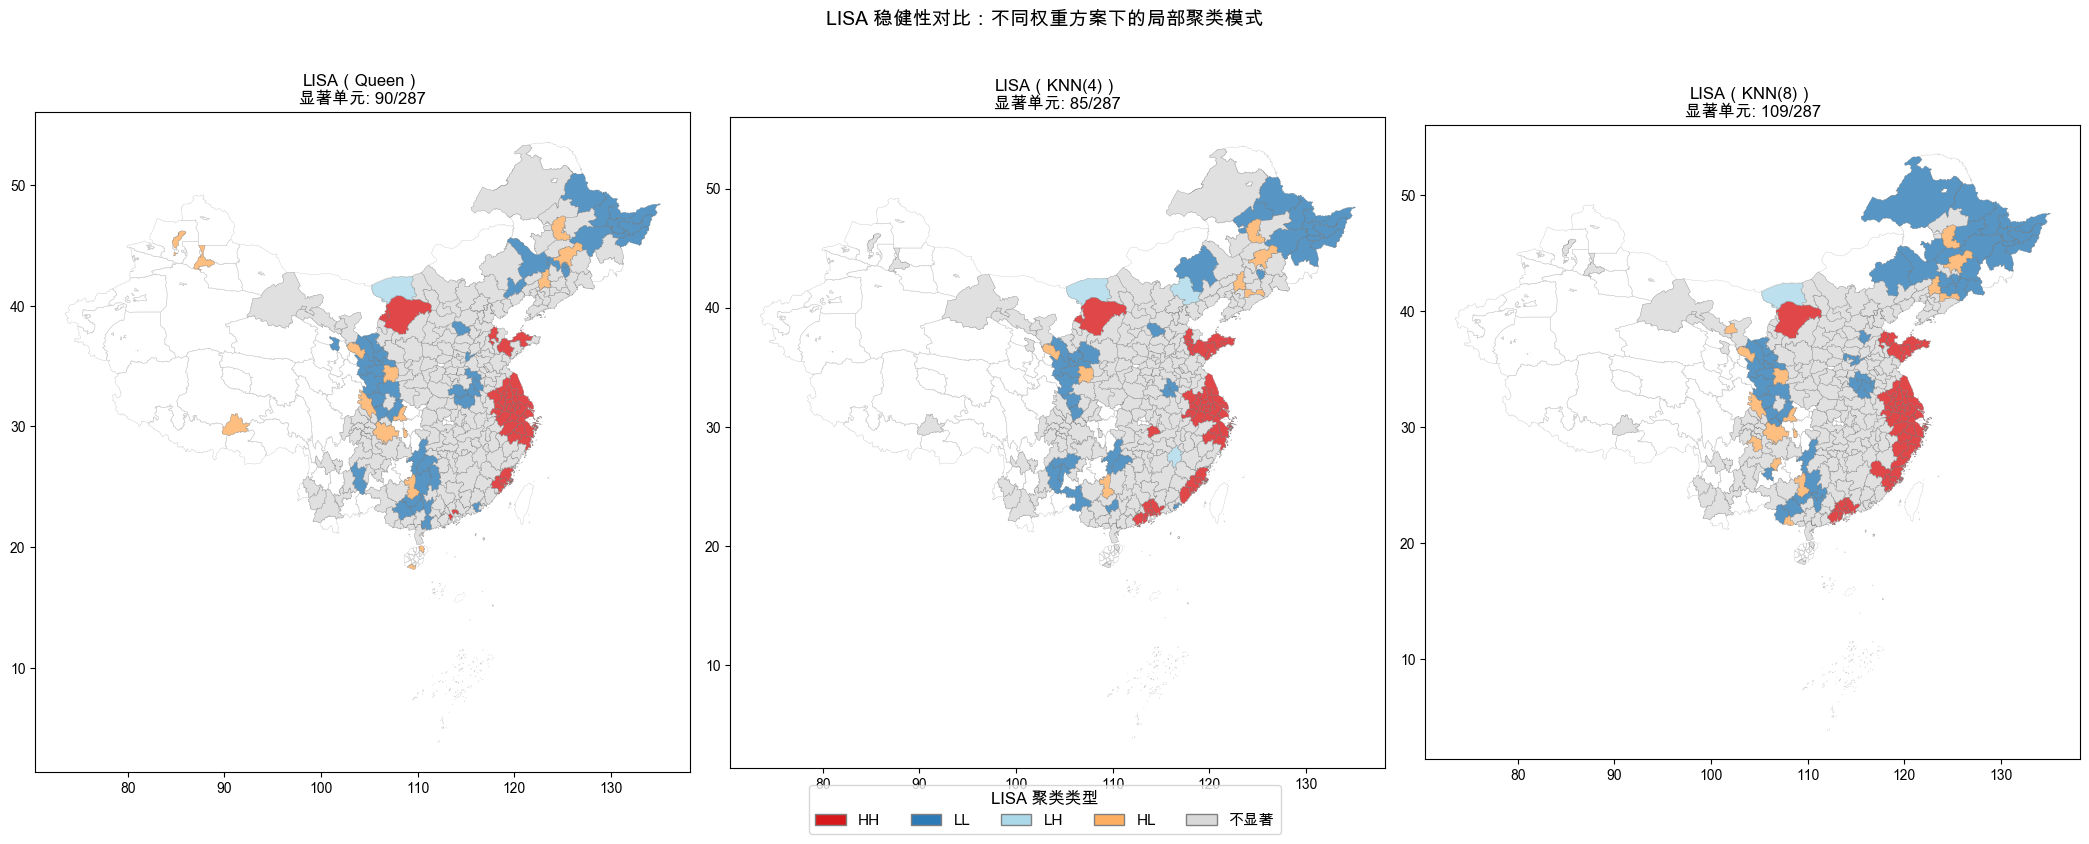

In [ ]:
# 6.3 LISA 稳健性对比 —— 多权重方案的 LISA 图
# ---------------------------------------------------------------
n_schemes = len(weight_schemes)
fig, axes = plt.subplots(1, n_schemes, figsize=(7 * n_schemes, 8))
if n_schemes == 1:
    axes = [axes]

lisa_colors = {0: '#d9d9d9', 1: '#d7191c', 2: '#abd9e9', 3: '#2c7bb6', 4: '#fdae61'}
lisa_class_labels = {0: '不显著', 1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}

for idx, (name, w) in enumerate(weight_schemes.items()):
    ax = axes[idx]

    # 底图：所有城市边界
    gdf.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidths=0.3)

    lisa_w = Moran_Local(y_values, w, permutations=999)

    labels_w = lisa_w.q
    sig_w = lisa_w.p_sim <= 0.05
    class_w = np.zeros(len(y_values), dtype=int)
    class_w[sig_w & (labels_w == 1)] = 1
    class_w[sig_w & (labels_w == 2)] = 2
    class_w[sig_w & (labels_w == 3)] = 3
    class_w[sig_w & (labels_w == 4)] = 4

    gdf_valid[f'lisa_{name}'] = class_w

    for cls in [1, 3, 2, 4, 0]:
        mask = gdf_valid[f'lisa_{name}'] == cls
        if mask.any():
            gdf_valid[mask].plot(ax=ax, facecolor=lisa_colors[cls],
                                  edgecolors='gray', linewidths=0.2, alpha=0.8)

    n_sig = np.sum(sig_w)
    ax.set_title(f'LISA（{name}）\n显著单元: {n_sig}/{len(y_values)}', fontsize=12)

legend_elements = [Patch(facecolor=lisa_colors[c], edgecolor='gray', label=lisa_class_labels[c])
                   for c in [1, 3, 2, 4, 0]]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11,
           title='LISA 聚类类型', title_fontsize=12, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('LISA 稳健性对比：不同权重方案下的局部聚类模式', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('output_08_lisa_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 6.4 案例总结（对应 Slide 58 + Slide 60）
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("案例总结 —— 核心发现（Slide 58）")
print("=" * 60)

primary_moran = moran_results[primary_w_name]
print(f"""
发现一：中国地级市{VAR_LABEL}存在高度显著的正空间自相关
  Moran's I = {primary_moran.I:.4f}, p = {primary_moran.p_sim:.6f}
  含义：经济发展水平相似的城市倾向在空间上聚集——"物以类聚"

发现二：HH 热点集中在长三角、珠三角、京津冀等发达城市群
  这些区域形成了成熟的经济集聚效应和正向溢出

发现三：LL 冷点分布在西部欠发达地区
  基础设施薄弱、地理位置偏远，可能陷入"低水平均衡陷阱"

发现四：空间异常值（HL/LH）揭示了区域发展不均衡性
  HL：资源型城市或政策特区，高值未有效扩散
  LH：被发达区域包围但自身滞后的城市

发现五：三种权重方案下结论高度一致 → 分析结果稳健
""")

print("-" * 60)
print("课堂讨论（Slide 60）：空间自相关是'因'还是'果'？")
print("-" * 60)
print("""
  检测到空间自相关只是故事的开始，不是结束。

  可能的空间过程：
  1. 空间溢出效应 → 自相关是因果机制
     例：北京经济发展带动周边河北城市
  2. 空间竞争效应 → 可能出现负自相关
     例：相邻城市争夺外资，"此消彼长"
  3. 空间分层效应 → 社会经济分选
     例：发达地区吸引人才，形成正向循环
  4. 伪自相关 → 混淆变量驱动
     例：地理位置（沿海/内陆）同时影响多个变量

  → 理解因果机制，才是空间分析的真正挑战！
""")

print("=" * 60)
print(f"分析完成！共生成 8 张结果图（output_01 ~ output_08.png）")
print("=" * 60)


案例总结 —— 核心发现（Slide 58）

发现一：中国地级市经济发展水平（ln(人均GDP)）存在高度显著的正空间自相关
  Moran's I = 0.4749, p = 0.001000
  含义：经济发展水平相似的城市倾向在空间上聚集——"物以类聚"

发现二：HH 热点集中在长三角、珠三角、京津冀等发达城市群
  这些区域形成了成熟的经济集聚效应和正向溢出

发现三：LL 冷点分布在西部欠发达地区
  基础设施薄弱、地理位置偏远，可能陷入"低水平均衡陷阱"

发现四：空间异常值（HL/LH）揭示了区域发展不均衡性
  HL：资源型城市或政策特区，高值未有效扩散
  LH：被发达区域包围但自身滞后的城市

发现五：三种权重方案下结论高度一致 → 分析结果稳健

------------------------------------------------------------
课堂讨论（Slide 60）：空间自相关是'因'还是'果'？
------------------------------------------------------------

  检测到空间自相关只是故事的开始，不是结束。

  可能的空间过程：
  1. 空间溢出效应 → 自相关是因果机制
     例：北京经济发展带动周边河北城市
  2. 空间竞争效应 → 可能出现负自相关
     例：相邻城市争夺外资，"此消彼长"
  3. 空间分层效应 → 社会经济分选
     例：发达地区吸引人才，形成正向循环
  4. 伪自相关 → 混淆变量驱动
     例：地理位置（沿海/内陆）同时影响多个变量

  → 理解因果机制，才是空间分析的真正挑战！

分析完成！共生成 8 张结果图（output_01 ~ output_08.png）
